<!-- Google Fonts -->
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600&family=Playfair+Display:wght@700;800&display=swap" rel="stylesheet">

<div style="
    padding:40px 20px;
    text-align:center;
">

<img src="https://static.wixstatic.com/media/e16f80_9c4ca79ed84340e0984c64712e35448c~mv2_d_3000_2100_s_2.png"
     width="170"
     style="margin-bottom:18px;">

<div style="
    font-family:'Inter',sans-serif;
    font-size:13px;
    letter-spacing:.6em;
    text-transform:uppercase;
    font-weight:300;
    color:white;
">
DATA MINING
</div>

<h1 style="
    font-family:'Playfair Display',serif;
    font-size:58px;
    font-weight:800;
    margin:10px 0 18px 0;
    color:white;
">
DBSCAN for Credit Card Fraud Detection
</h1>

<p style="
    font-family:'Inter',sans-serif;
    font-size:18px;
    font-weight:300;
    color:white;
">
Density-Based Clustering for Unsupervised Anomaly Detection
</p>

<div style="
    display:inline-block;
    text-align:left;
    margin-top:22px;
    font-family:'Inter',sans-serif;
    font-size:16px;
    color:white;
">

<b>Made by</b>

<ul style="margin-top:10px; line-height:1.8;">
    <li>Jorge Enrique Vargas Pech</li>
    <li>Jose Luis Rejón Quintal</li>
    <li>Saúl Ruiz Peña</li>
    <li>William Emmanuel Fernández Castillo</li>
</ul>

</div>

<br><br>

<p>
<img src="https://img.shields.io/badge/Python-0D1117?style=flat-square&logo=python&logoColor=white"/>
<img src="https://img.shields.io/badge/Machine%20Learning-0D1117?style=flat-square&logo=scikitlearn&logoColor=white"/>
<img src="https://img.shields.io/badge/DBSCAN-0D1117?style=flat-square&logoColor=white"/>
<img src="https://img.shields.io/badge/Clustering-0D1117?style=flat-square&logoColor=white"/>
<img src="https://img.shields.io/badge/Data%20Science-0D1117?style=flat-square&logo=jupyter&logoColor=white"/>
</p>

</div>

## Purpose

In this practice, you will use **DBSCAN** to detect unusual credit card transactions. The method is **unsupervised**: the algorithm will not use the fraud label during training. The label `Class` will be used only at the end to evaluate whether the points marked as noise are related to actual fraud cases.

## Learning goals

By the end of the activity, you should be able to:

- Explain how DBSCAN uses density to form clusters and detect noise.
- Prepare a numerical dataset for a distance-based algorithm.
- Select tentative DBSCAN parameters using a k-distance plot.
- Treat DBSCAN noise points as possible anomalies.
- Evaluate anomaly flags against known labels using precision, recall, F1-score, and a confusion matrix.

## DBSCAN in one page

**DBSCAN** stands for *Density-Based Spatial Clustering of Applications with Noise*. It groups observations that are close to many other observations and marks isolated observations as noise. In anomaly detection, those noise points are treated as candidates for unusual behavior.

### Main parameters

- **eps**: neighborhood radius. Two points are neighbors if their distance is at most `eps`.
- **min_samples**: minimum number of observations required to form a dense region.
- **Metric**: distance function used by DBSCAN. In this activity, use Euclidean distance after scaling.

### Important interpretation rule

> A DBSCAN noise point is **not** automatically a fraudulent transaction. It only means that the transaction is located in a low-density region of the feature space. The business interpretation is: this transaction deserves attention because it does not look similar to most transactions in the sample.


## 1. Setup and dataset access
### Dataset

Use the **Credit Card Fraud Detection** dataset from Kaggle:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The file you need is `creditcard.csv`. It contains anonymized numerical features `V1` to `V28`, `Time`, `Amount`, and `Class`. The target label is `Class`, where **1** means fraud and **0** means legitimate.



In [1]:
%pip install -q pandas numpy matplotlib scikit-learn

from pathlib import Path
import zipfile

DATA_PATH = Path("creditcard.csv")
ZIP_PATH = Path("creditcardfraud.zip")

if not DATA_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(".")

print(f"Dataset ready: {DATA_PATH.resolve()}")


Note: you may need to restart the kernel to use updated packages.
Dataset ready: /home/yorch/Documentos/GitHub/DBSCAN_Fraud_Detection_Practice/creditcard.csv


## 2. Data loading and first inspection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("creditcard.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check the expected columns and the target distribution.


In [3]:
expected_columns = {"Time", "Amount", "Class"} | {f"V{i}" for i in range(1, 29)}
missing_columns = expected_columns - set(df.columns)

print("Missing expected columns:", missing_columns)
print("\nClass counts:")
print(df["Class"].value_counts().sort_index())
print("\nClass percentage:")
print(df["Class"].value_counts(normalize=True).sort_index().mul(100).round(4))

assert len(missing_columns) == 0, "Some expected columns are missing."
assert df["Class"].isin([0, 1]).all(), "Class must contain only 0 and 1."


Missing expected columns: set()

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


Inspect missing values and basic statistics for `Time`, `Amount`, and `Class`.


In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary.head(10))
display(df[["Time", "Amount", "Class"]].describe().T)
display(df.groupby("Class")["Amount"].describe())


Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Create two simple plots.


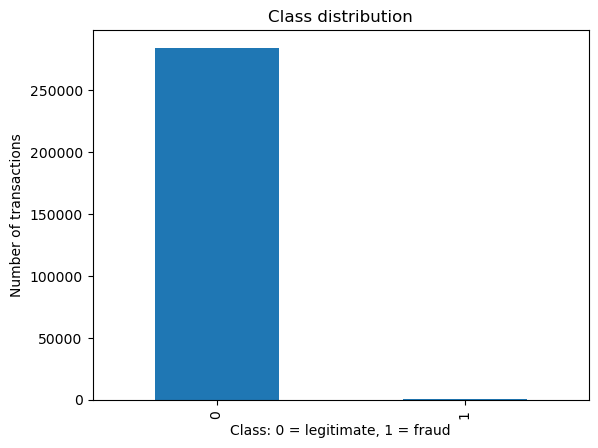

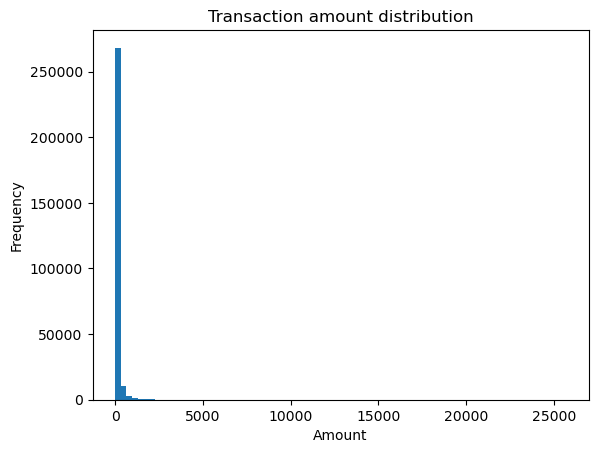

In [5]:
ax = df["Class"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Class distribution")
ax.set_xlabel("Class: 0 = legitimate, 1 = fraud")
ax.set_ylabel("Number of transactions")
plt.show()

ax = df["Amount"].plot(kind="hist", bins=80)
ax.set_title("Transaction amount distribution")
ax.set_xlabel("Amount")
plt.show()


## 3. Feature preparation

DBSCAN is distance-based. Features with larger scales can dominate the distance calculation, so all input variables must be **scaled**. The label `Class` must **not** be included in the DBSCAN input matrix.

For classroom efficiency, use a guided subset that contains all fraud cases and a sample of legitimate transactions. This keeps the runtime manageable and gives enough fraud cases for evaluation. The label is used only to build an educational subset and later evaluate the result; it is **not** used by DBSCAN during fitting.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
N_NORMAL = 2000

normal_df = df[df["Class"] == 0].sample(n=N_NORMAL, random_state=RANDOM_STATE)
fraud_df = df[df["Class"] == 1]
work_df = (
    pd.concat([normal_df, fraud_df], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Working dataset shape:", work_df.shape)
print(work_df["Class"].value_counts().sort_index())


Working dataset shape: (2492, 31)
Class
0    2000
1     492
Name: count, dtype: int64


Build the input matrix, scale it, and create the lower-dimensional modeling matrix used by DBSCAN.


In [7]:
feature_cols = [col for col in work_df.columns if col != "Class"]
X = work_df[feature_cols].copy()
y = work_df["Class"].astype(int).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Input matrix shape:", X_scaled.shape)
print("Number of labels stored for evaluation:", y.shape[0])


Input matrix shape: (2492, 30)
Number of labels stored for evaluation: 2492


Create a two-dimensional PCA projection **only for visualization**. DBSCAN will be fitted on a **10-dimensional** PCA modeling matrix created from the scaled features. This keeps the practice computationally manageable and reduces the effect of high-dimensional distance concentration.


Modeling matrix shape: (2492, 10)
Explained variance in 10 components: 0.7589


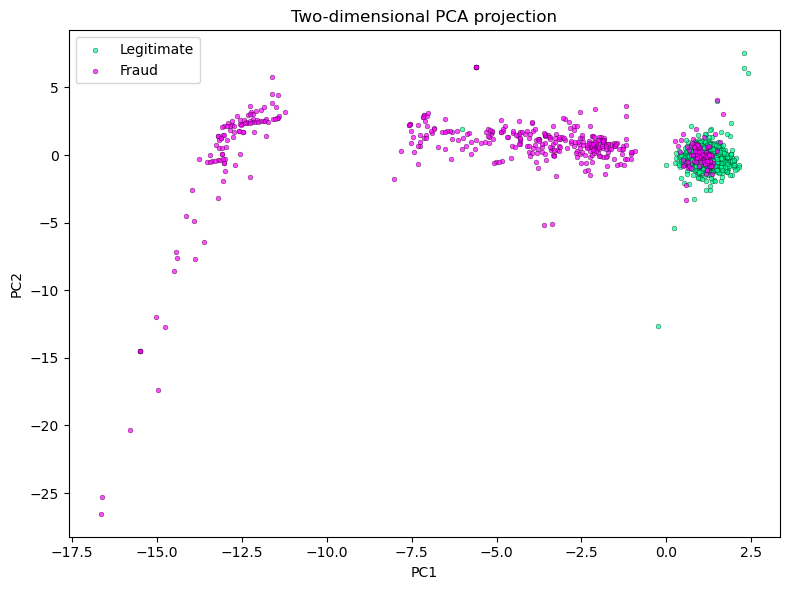

In [8]:
pca_model = PCA(n_components=10, random_state=RANDOM_STATE)
X_model = pca_model.fit_transform(X_scaled)

print("Modeling matrix shape:", X_model.shape)
print("Explained variance in 10 components:", round(pca_model.explained_variance_ratio_.sum(), 4))

pca_df = pd.DataFrame(X_model[:, :2], columns=["PC1", "PC2"])
pca_df["Class"] = y.values

colors = np.where(pca_df["Class"] == 1, "#FF00FF", "#00FF96")  # magenta vs neon green
fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0, "#00FF96", "Legitimate"), (1, "#FF00FF", "Fraud")]:
    mask = y.values == cls
    ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
               c=color, s=12, alpha=0.7, label=label, edgecolors="black", linewidths=0.3)
ax.set_title("Two-dimensional PCA projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Choosing DBSCAN parameters

The two key parameters are **eps** and **min_samples**. A common starting point is to set `min_samples` between the number of dimensions and a smaller practical value. For this activity, start with `min_samples = 15` to keep the model interpretable and computationally manageable.

A **k-distance plot** helps you choose a tentative `eps`. For each point, compute the distance to its k-th nearest neighbor. Sort those distances from smallest to largest and look for an elbow or sudden increase.

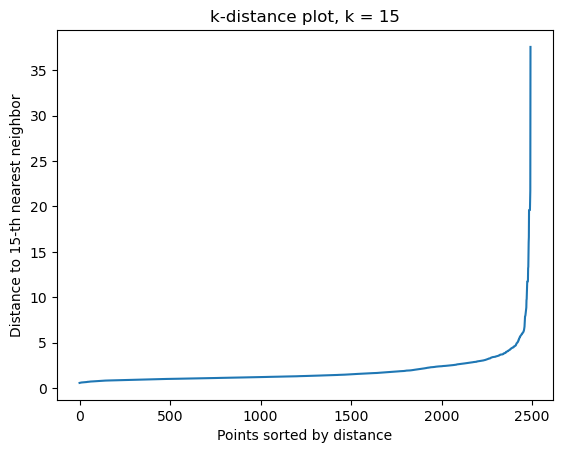

In [9]:
from sklearn.neighbors import NearestNeighbors

min_samples = 15
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_model)
distances, indices = neighbors.kneighbors(X_model)
k_distances = np.sort(distances[:, -1])

ax = pd.Series(k_distances).plot()
ax.set_title(f"k-distance plot, k = {min_samples}")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.show()


Zoom into the upper tail of the plot, where the elbow is usually easier to see.


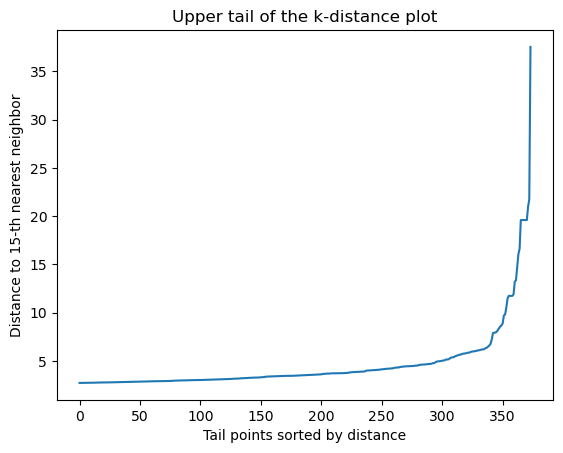

In [10]:
tail_start = int(0.85 * len(k_distances))
ax = pd.Series(k_distances[tail_start:]).reset_index(drop=True).plot()
ax.set_title("Upper tail of the k-distance plot")
ax.set_xlabel("Tail points sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.show()


In [11]:
print("Useful percentiles for eps exploration:")
for q in [85, 90, 92, 95, 97, 99]:
    print(q, np.percentile(k_distances, q).round(4))


Useful percentiles for eps exploration:
85 2.7044
90 3.1067
92 3.4395
95 4.0853
97 4.9622
99 8.5688


Use the k-distance plot and percentiles to guide `eps`. If the selected model returns almost no noise points, **reduce** `eps`. If it returns almost every point as noise, **increase** `eps` and rerun the search.


Based on the k-distance plot and the percentile table above, the elbow sits between the 85th and 90th percentiles: distances are still rising gently up to that point and then start climbing faster. We manually pick `eps` at the **90th percentile**, right at that bend, rather than searching automatically over the candidates.

In [12]:
chosen_eps = round(float(np.percentile(k_distances, 90)), 2)

print("chosen_eps:", chosen_eps)
print("min_samples:", min_samples)

chosen_eps: 3.11
min_samples: 15


## 5. Fitting DBSCAN and visualizing anomalies

Fit DBSCAN using the PCA modeling matrix. DBSCAN labels noise points as **-1**. Treat those noise points as possible anomalies.

In [13]:
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps=chosen_eps,
    min_samples=min_samples,
    metric="euclidean",
    n_jobs=-1
)
labels = model.fit_predict(X_model)

work_df["dbscan_label"] = labels
work_df["is_noise"] = (labels == -1).astype(int)
work_df["k_distance"] = distances[:, -1]

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(work_df["is_noise"].sum())
noise_rate = work_df["is_noise"].mean()

print("Number of clusters:", n_clusters)
print("Noise points:", n_noise)
print("Noise rate:", round(noise_rate, 4))


Number of clusters: 3
Noise points: 128
Noise rate: 0.0514


Visualize the model output on the PCA projection.


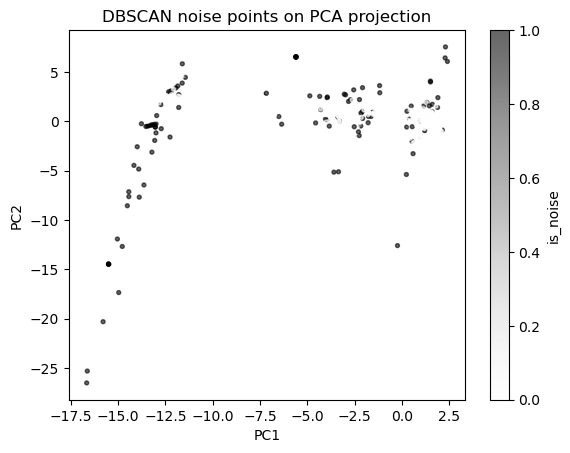

In [14]:
pca_df["dbscan_label"] = work_df["dbscan_label"].values
pca_df["is_noise"] = work_df["is_noise"].values

ax = pca_df.plot(kind="scatter", x="PC1", y="PC2", c="is_noise", s=8, alpha=0.6)
ax.set_title("DBSCAN noise points on PCA projection")
plt.show()


Inspect the observations that look most isolated according to the k-distance value.


In [15]:
columns_to_view = ["Time", "Amount", "Class", "dbscan_label", "is_noise", "k_distance"]
top_isolated = (
    work_df[columns_to_view]
    .sort_values("k_distance", ascending=False)
    .head(15)
)
display(top_isolated)


,Time,Amount,Class,dbscan_label,is_noise,k_distance
1826,160204.0,1441.06,0,-1,1,37.548059
1455,102572.0,0.01,1,-1,1,21.739564
1355,102114.0,0.00,1,-1,1,20.975901
161,68207.0,1.00,1,-1,1,19.595758
1055,68207.0,1.00,1,-1,1,19.595758
954,68207.0,1.00,1,-1,1,19.595758
763,68207.0,1.00,1,-1,1,19.595758
787,68207.0,1.00,1,-1,1,19.595758
1849,68207.0,1.00,1,-1,1,19.595758
1273,18088.0,1218.89,1,-1,1,16.609201


Run a small **sensitivity analysis**. This does not replace the k-distance plot; it helps you observe how `eps` changes the number of noise points and the detection metrics.


,eps,clusters,noise_points,noise_rate,precision,recall,f1
0,2.0,2,503,0.2018,0.7555,0.7724,0.7638
1,2.5,3,269,0.1079,0.7546,0.4126,0.5335
2,3.0,3,140,0.0562,0.7929,0.2256,0.3513
3,3.5,3,94,0.0377,0.7553,0.1443,0.2423
4,4.0,2,73,0.0293,0.7397,0.1098,0.1912
5,4.5,2,55,0.0221,0.7273,0.0813,0.1463
6,5.0,1,35,0.0140,0.6571,0.0467,0.0873
7,5.5,1,31,0.0124,0.6774,0.0427,0.0803
8,6.0,1,25,0.0100,0.7200,0.0366,0.0696


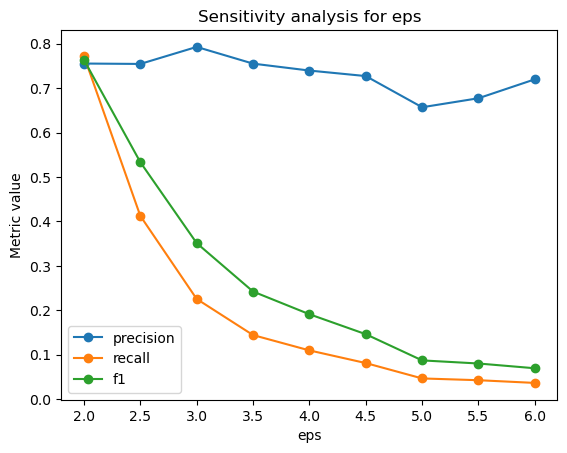

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

eps_values = np.arange(2.0, 6.1, 0.5)
results = []
for eps in eps_values:
    temp_model = DBSCAN(eps=float(eps), min_samples=min_samples, metric="euclidean", n_jobs=-1)
    temp_labels = temp_model.fit_predict(X_model)
    temp_pred = (temp_labels == -1).astype(int)
    temp_clusters = len(set(temp_labels)) - (1 if -1 in temp_labels else 0)
    results.append({
        "eps": round(float(eps), 2),
        "clusters": temp_clusters,
        "noise_points": int(temp_pred.sum()),
        "noise_rate": round(float(temp_pred.mean()), 4),
        "precision": round(precision_score(y, temp_pred, zero_division=0), 4),
        "recall": round(recall_score(y, temp_pred, zero_division=0), 4),
        "f1": round(f1_score(y, temp_pred, zero_division=0), 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

ax = results_df.plot(x="eps", y=["precision", "recall", "f1"], marker="o")
ax.set_title("Sensitivity analysis for eps")
ax.set_ylabel("Metric value")
plt.show()

## 6. Evaluation against the fraud label

Use `Class` **only now**. The model has already produced an anomaly flag without seeing the label. Evaluate how often DBSCAN noise points match actual fraud transactions.

> **Note:** `Class` was **not** used during DBSCAN fitting — only for evaluation.

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = work_df["is_noise"].astype(int)
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual legitimate", "Actual fraud"],
    columns=["Predicted clustered", "Predicted noise"]
)
display(cm_df)

print(classification_report(
    y,
    y_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

,Predicted clustered,Predicted noise
Actual legitimate,1972,28
Actual fraud,392,100


              precision    recall  f1-score   support

  Legitimate       0.83      0.99      0.90      2000
       Fraud       0.78      0.20      0.32       492

    accuracy                           0.83      2492
   macro avg       0.81      0.59      0.61      2492
weighted avg       0.82      0.83      0.79      2492



Compute a compact fraud-detection summary.


In [18]:
actual_frauds = int((y == 1).sum())
detected_frauds = int(((y == 1) & (y_pred == 1)).sum())
false_alerts = int(((y == 0) & (y_pred == 1)).sum())
missed_frauds = int(((y == 1) & (y_pred == 0)).sum())

summary = pd.DataFrame({
    "metric": [
        "Actual frauds",
        "Detected frauds as noise",
        "Missed frauds",
        "False alerts",
        "Fraud recall",
        "Alert precision"
    ],
    "value": [
        actual_frauds,
        detected_frauds,
        missed_frauds,
        false_alerts,
        round(detected_frauds / actual_frauds, 4),
        round(detected_frauds / (detected_frauds + false_alerts), 4)
    ]
})
display(summary)


,metric,value
0,Actual frauds,492.0000
1,Detected frauds as noise,100.0000
2,Missed frauds,392.0000
3,False alerts,28.0000
4,Fraud recall,0.2033
5,Alert precision,0.7812


### Technical interpretation

We ran DBSCAN with `eps = 3.11` and `min_samples = 15`, picked straight from the 90th percentile of the k-distance plot.

- 128 out of 2,492 transactions (5.14%) came out as noise.
- For the fraud class: precision 0.78, recall 0.20, F1 0.32. So when the model flags something as noise it's usually right (0.78 precision), but it only catches about 1 in 5 actual frauds — most of them end up inside a cluster instead of standing out as noise.
- **Noise is not fraud.** A noise point only means the transaction sits in a low-density region of the feature space. Some legitimate transactions get flagged too, and plenty of fraud cases stay hidden inside dense clusters, so this flag is a prompt for human review, not a verdict.

## 7. Notebook organization and reproducibility

Before submitting, restart the kernel and run all cells from top to bottom. The notebook expects `creditcard.csv` (or `creditcardfraud.zip`) in the working directory and should complete without manual edits.

**Checklist:**
- All code cells run in order with visible outputs.
- Variable names follow the activity (`df`, `work_df`, `X_model`, `chosen_eps`, `min_samples`, `y_pred`).
- Each major section includes a short markdown explanation before the code.
- No unrelated experiments are included beyond the DBSCAN workflow.


## References

- Ester, M., Kriegel, H.-P., Sander, J., and Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.* Proceedings of KDD-96, 226–231.
- Kaggle/ULB. Credit Card Fraud Detection dataset. https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Scikit-learn. DBSCAN documentation. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
- Porwal, U., and Mukund, S. (2018). *Credit Card Fraud Detection in e-Commerce: An Outlier Detection Approach.* https://arxiv.org/abs/1811.02196
- Niu, X., Wang, L., and Yang, X. (2019). *A Comparison Study of Credit Card Fraud Detection: Supervised versus Unsupervised.* https://arxiv.org/abs/1904.10604